# 03 · Execution Time Analysis

This notebook analyses execution time across languages and its relationship to energy.

**Units:** Time values are in **milliseconds (ms)** (converted from raw µs at load time).
Energy values are in **Joules (J)**.

**Key questions:**
- Which languages execute fastest?
- How does time correlate with CPU and memory energy?
- What is the Energy-Delay Product (EDP = CPU energy × time, in J·ms)?

**Methodology:** Rankings (time, EDP) and heatmaps use the **two-step mean** (equal
benchmark weight) from `results_clean.csv` via `lang_means()`. Spearman correlation is
used for the energy↔time relationship (more robust than Pearson for right-skewed data),
and the paradigm comparison keeps the non-parametric Kruskal-Wallis / Mann-Whitney tests.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations
from pathlib import Path
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150, 'figure.figsize': (12, 6)})

In [2]:
# ── Column names as they appear in results_clean_runs.csv ────────────────────
# Units already converted by notebooks/01_data_cleaning.ipynb
COL_CPU_ENERGY = 'cpu_energy_rapl_msr_component-package_0-j'
COL_MEM_ENERGY = 'memory_energy_rapl_msr_component-dram_0-j'
COL_TIME       = 'phase_time_syscall_system-system-ms'
COL_CPU_CARBON = 'cpu_carbon_rapl_msr_component-package_0-g'
COL_MEM_CARBON = 'memory_carbon_rapl_msr_component-dram_0-g'

ALPHA = 0.05

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR = Path('outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

LANG_DISPLAY = {
    'c': 'C', 'cpp': 'C++', 'csharp': 'C#', 'fsharp': 'F#',
    'nodejs': 'JavaScript', 'dart': 'Dart', 'erlang': 'Erlang',
    'go': 'Go', 'haskell': 'Haskell', 'java': 'Java', 'lua': 'Lua',
    'ocaml': 'OCaml', 'perl': 'Perl', 'php': 'PHP',
    'python': 'Python', 'ruby': 'Ruby', 'rust': 'Rust', 'swift': 'Swift',
}

PARADIGM = {
    'C': 'AOT', 'C++': 'AOT', 'C#': 'AOT', 'Dart': 'AOT', 'Go': 'AOT',
    'Haskell': 'AOT', 'Java': 'AOT', 'OCaml': 'AOT', 'Rust': 'AOT', 'Swift': 'AOT',
    'Erlang': 'JIT', 'F#': 'JIT', 'JavaScript': 'JIT', 'PHP': 'JIT', 'Ruby': 'JIT',
    'Lua': 'Interpreted', 'Perl': 'Interpreted', 'Python': 'Interpreted',
}

PARADIGM_COLORS = {'AOT': '#2980b9', 'JIT': '#e67e22', 'Interpreted': '#27ae60'}
PARADIGM_ORDER  = ['AOT', 'JIT', 'Interpreted']

# Marker style for the mean (▲) overlaid on boxplots/violins (showmeans=True).
MEANPROPS = dict(marker='^', markerfacecolor='white', markeredgecolor='black', markersize=6)

# Data pre-cleaned by notebooks/01_data_cleaning.ipynb:
#   - Outliers removed per (language × benchmark) group, IQR fence on CPU energy + time
#   - Units already converted (J, ms, g, MB, W)
#
# Single source: results_clean_runs.csv — per-run rows.
#   df       = all per-run rows, used for distribution views and non-parametric tests.
#   df_mean  = per-(language × benchmark) mean, computed here from df.
#              Rankings, heatmaps and summary tables use df_mean via lang_means().
df = pd.read_csv('../../results/results_clean_runs.csv')
df['language'] = df['language'].replace(LANG_DISPLAY)
df['paradigm'] = df['language'].map(PARADIGM)

_id_cols = {'run_id', 'measured_at', 'language', 'benchmark', 'paradigm'}
_metric_cols = [c for c in df.columns if c not in _id_cols]
df_mean = df.groupby(['language', 'benchmark'])[_metric_cols].mean().reset_index()
df_mean['paradigm'] = df_mean['language'].map(PARADIGM)

# Energy-Delay Product from representative (mean) values per cell: lower is better.
# EDP = (CPU + Memory energy) × time, in J·ms.
df_mean['EDP'] = (df_mean[COL_CPU_ENERGY] + df_mean[COL_MEM_ENERGY]) * df_mean[COL_TIME]


def lang_means(cols):
    """Per-language two-step mean for column(s) `cols` (str or list): average the
    per-benchmark cell means with equal benchmark weight. Returns a Series for a
    single column or a DataFrame for a list. Derived from results_clean_runs.csv."""
    return df_mean.groupby('language')[cols].mean()


print(f"Runs shape: {df.shape} | Cell-means shape: {df_mean.shape}")
print(f"Languages ({df['language'].nunique()}): {sorted(df['language'].unique())}")
print(f"Benchmarks ({df['benchmark'].nunique()}): {sorted(df['benchmark'].unique())}")
print("Units: energy=J | time=ms | carbon=g | disk/net=MB | power=W")
print("Rankings use the two-step mean (equal benchmark weight) via lang_means(); "
      "boxplots/violins and non-parametric tests use the per-run df.")
df_mean.head(3)

Runs shape: (1280, 17) | Cell-means shape: (144, 16)
Languages (18): ['C', 'C#', 'C++', 'Dart', 'Erlang', 'F#', 'Go', 'Haskell', 'Java', 'JavaScript', 'Lua', 'OCaml', 'PHP', 'Perl', 'Python', 'Ruby', 'Rust', 'Swift']
Benchmarks (8): ['binary-trees', 'fannkuch-redux', 'fasta', 'k-nucleotide', 'mandelbrot', 'n-body', 'regex-redux', 'spectral-norm']
Units: energy=J | time=ms | carbon=g | disk/net=MB | power=W
Rankings use the two-step mean (equal benchmark weight) via lang_means(); boxplots/violins and non-parametric tests use the per-run df.


,language,benchmark,cpu_carbon_rapl_msr_component-package_0-g,cpu_energy_rapl_msr_component-package_0-j,disk_total_read_cgroup_container-container-mb,disk_total_write_cgroup_container-container-mb,embodied_carbon_share_machine-system-g,memory_carbon_rapl_msr_component-dram_0-g,memory_energy_rapl_msr_component-dram_0-j,network_carbon_formula_global-formula-g,network_energy_formula_global-formula-j,network_power_formula_global-formula-w,network_total_cgroup_container-container-mb,phase_time_syscall_system-system-ms,paradigm,EDP
0,C,binary-trees,0.002967,31.976886,0.192512,0.0,0.001753,0.000122,1.311170,0.000000e+00,0.000000,0.0,0.000000,1221.817400,AOT,40671.925300
1,C,fannkuch-redux,0.006453,69.556996,0.000000,0.0,0.003131,0.000063,0.682479,5.714286e-07,0.005702,0.0,0.000039,2182.097714,AOT,153269.397538
2,C,fasta,0.003574,38.523294,0.000000,0.0,0.002074,0.000081,0.870375,1.666667e-06,0.018067,0.0,0.000122,1445.462222,AOT,56942.061458


## 1. Execution Time by Language

Boxplots sorted by **mean** execution time (ms), with the mean marked (▲). Log scale is used
because time spans several orders of magnitude across languages and benchmarks. The box still
shows the median/quartiles as a distribution reference.

/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58188/4030070152.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


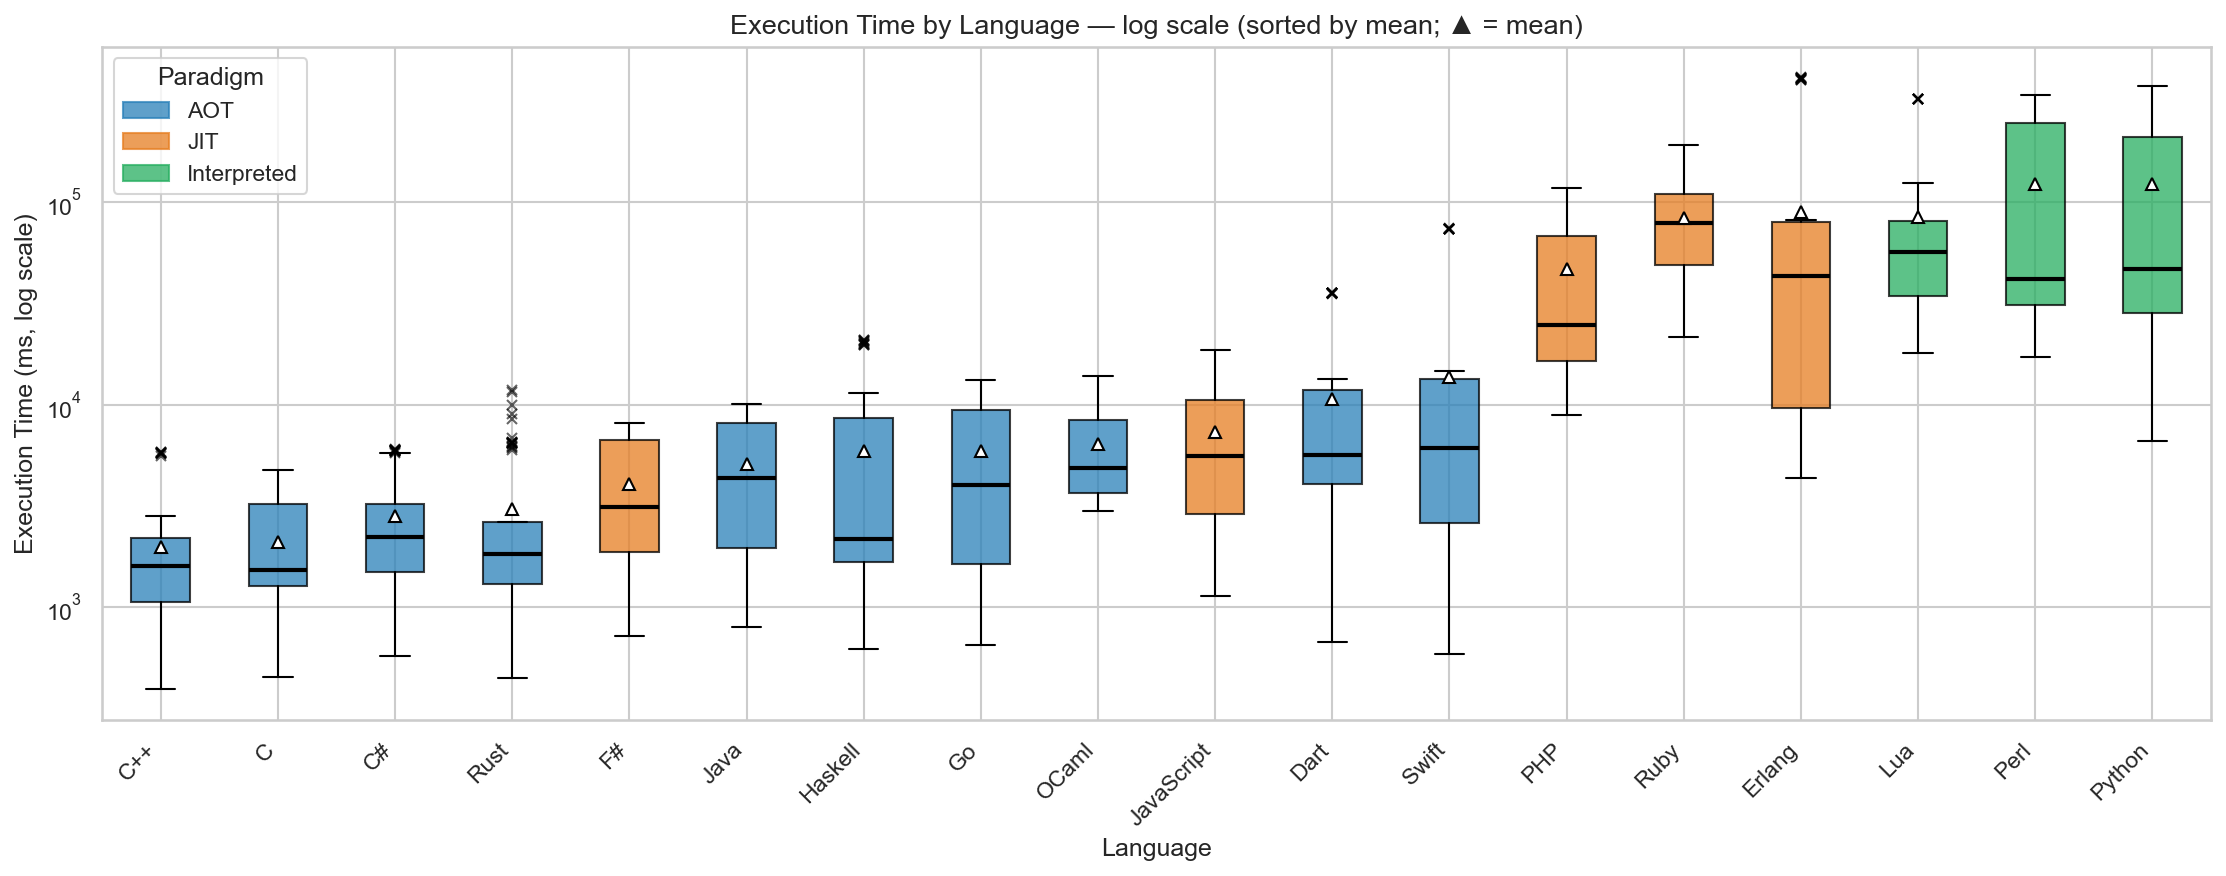

In [3]:
time_mean = lang_means(COL_TIME)
lang_order_time = time_mean.sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(15, 6))
bp = ax.boxplot(
    [df[df['language'] == lang][COL_TIME].values for lang in lang_order_time],
    labels=lang_order_time, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='x', markerfacecolor='red', markersize=5, alpha=0.6),
)
for patch, lang in zip(bp['boxes'], lang_order_time):
    patch.set_facecolor(PARADIGM_COLORS[PARADIGM[lang]])
    patch.set_alpha(0.75)

ax.set_yscale('log')
ax.set_title('Execution Time by Language — log scale (sorted by mean; ▲ = mean)', fontsize=13)
ax.set_xlabel('Language')
ax.set_ylabel('Execution Time (ms, log scale)')
legend_handles = [mpatches.Patch(color=PARADIGM_COLORS[p], label=p, alpha=0.75)
                  for p in PARADIGM_ORDER]
ax.legend(handles=legend_handles, title='Paradigm', loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'time_by_language.png', bbox_inches='tight')
plt.show()

/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58188/1847603898.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=langs, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58188/1847603898.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=langs, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58188/1847603898.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=langs, patch_artist=True, sh

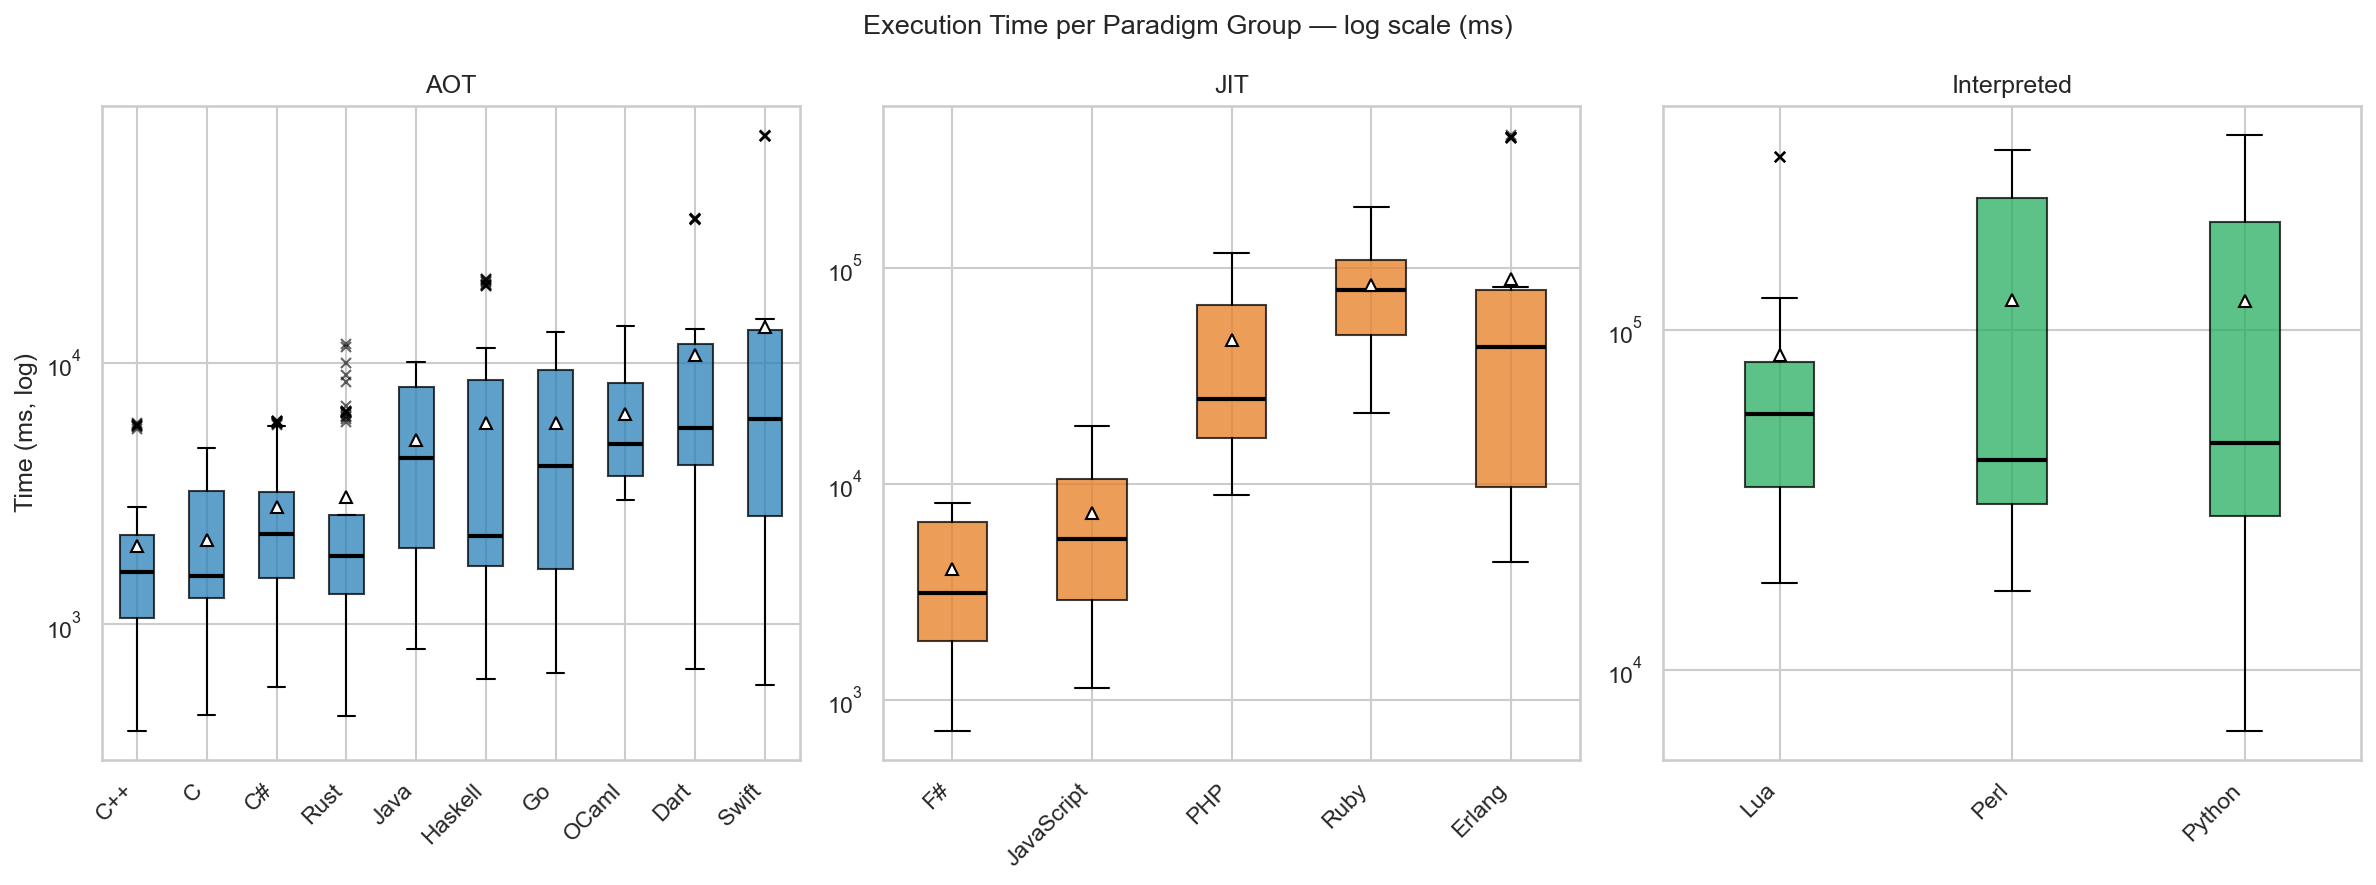

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
for ax, paradigm in zip(axes, PARADIGM_ORDER):
    langs = [l for l in lang_order_time if PARADIGM[l] == paradigm]
    data  = [df[df['language'] == l][COL_TIME].values for l in langs]
    bp = ax.boxplot(data, labels=langs, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='x', markerfacecolor='red', markersize=5, alpha=0.6))
    for patch in bp['boxes']:
        patch.set_facecolor(PARADIGM_COLORS[paradigm])
        patch.set_alpha(0.75)
    ax.set_yscale('log')
    ax.set_title(f'{paradigm}')
    ax.set_ylabel('Time (ms, log)' if paradigm == 'AOT' else '')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.suptitle('Execution Time per Paradigm Group — log scale (ms)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'time_per_paradigm.png', bbox_inches='tight')
plt.show()

## 2. Time vs CPU Energy

Scatter plot of mean execution time (ms) vs mean CPU energy (J) per language (two-step mean).
A strong correlation is expected. The quadrants reveal interesting outliers:
- **Top-left**: fast but energy-hungry (parallel overhead?)
- **Bottom-right**: slow but energy-efficient

Spearman r(time ms, CPU energy J) = 0.9794, p = 0.0000


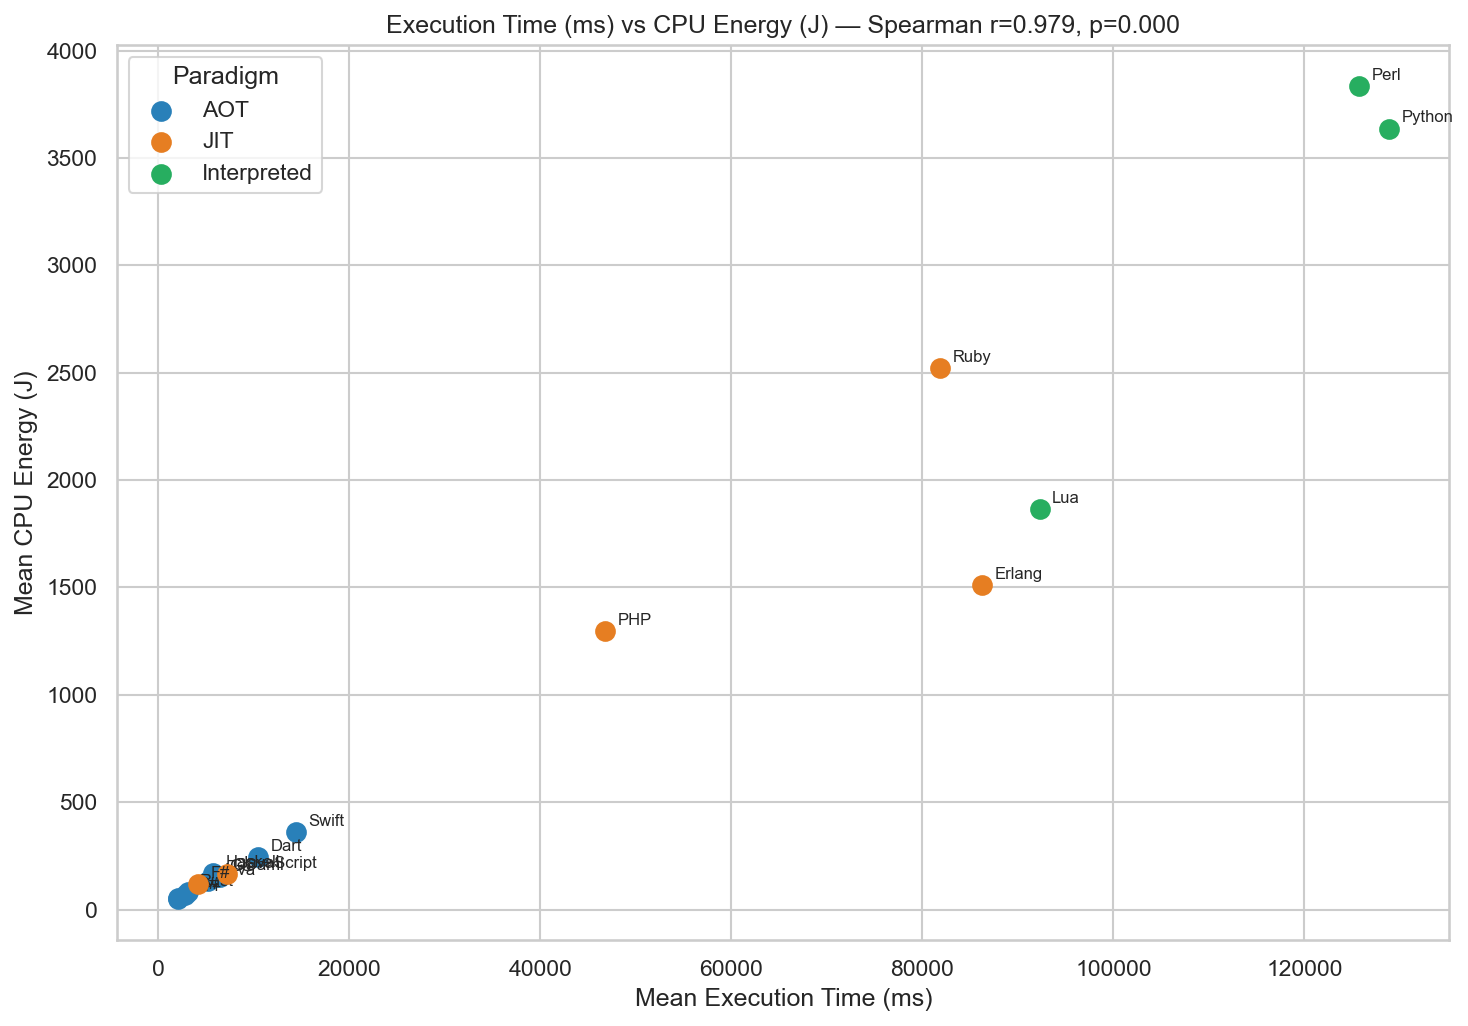

In [5]:
agg_time = df_mean.groupby('language').agg(
    time_mean  = (COL_TIME, 'mean'),
    cpu_mean   = (COL_CPU_ENERGY, 'mean'),
    mem_mean   = (COL_MEM_ENERGY, 'mean'),
    paradigm   = ('paradigm', 'first'),
).reset_index()

r, p = stats.spearmanr(agg_time['time_mean'], agg_time['cpu_mean'])
print(f"Spearman r(time ms, CPU energy J) = {r:.4f}, p = {p:.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
for paradigm in PARADIGM_ORDER:
    sub = agg_time[agg_time['paradigm'] == paradigm]
    ax.scatter(sub['time_mean'], sub['cpu_mean'],
               color=PARADIGM_COLORS[paradigm], label=paradigm, s=80, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['language'],
                    (row['time_mean'], row['cpu_mean']),
                    textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Mean Execution Time (ms)')
ax.set_ylabel('Mean CPU Energy (J)')
ax.set_title(f'Execution Time (ms) vs CPU Energy (J) — Spearman r={r:.3f}, p={p:.3f}', fontsize=12)
ax.legend(title='Paradigm')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'time_vs_cpu_energy.png', bbox_inches='tight')
plt.show()

## 3. Time vs Memory Energy

Same analysis for Memory Energy (J). Memory energy tends to correlate less tightly with
time because DRAM power draw depends more on allocation patterns than execution duration.

Spearman r(time ms, Memory energy J) = 0.9649, p = 0.0000


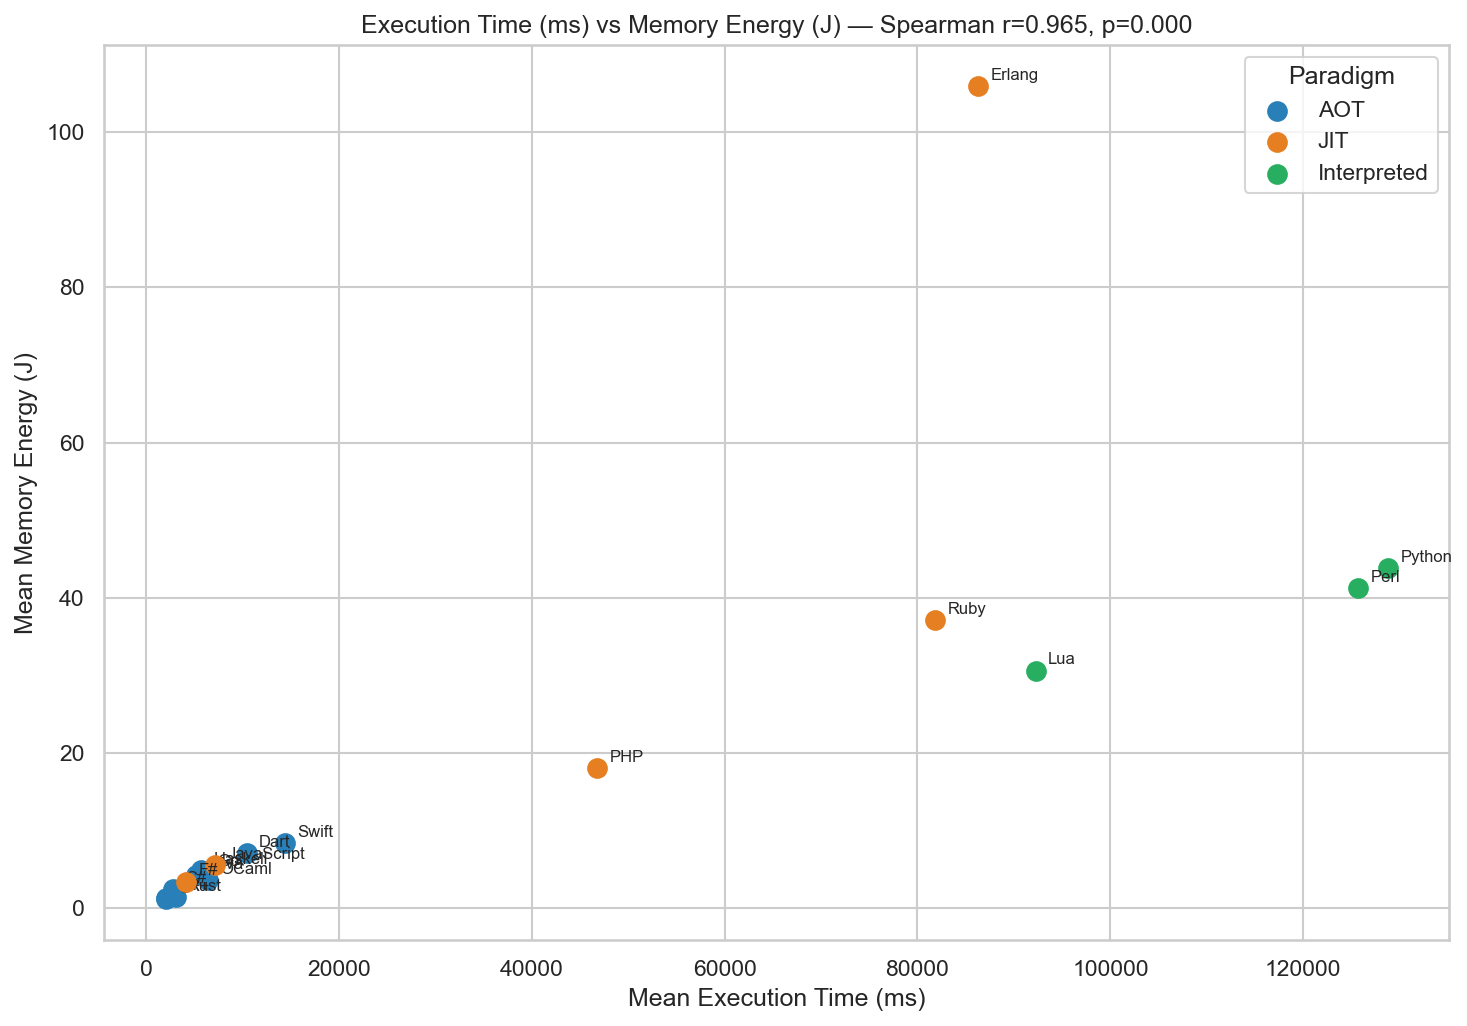

In [6]:
r_mem, p_mem = stats.spearmanr(agg_time['time_mean'], agg_time['mem_mean'])
print(f"Spearman r(time ms, Memory energy J) = {r_mem:.4f}, p = {p_mem:.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
for paradigm in PARADIGM_ORDER:
    sub = agg_time[agg_time['paradigm'] == paradigm]
    ax.scatter(sub['time_mean'], sub['mem_mean'],
               color=PARADIGM_COLORS[paradigm], label=paradigm, s=80, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['language'],
                    (row['time_mean'], row['mem_mean']),
                    textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Mean Execution Time (ms)')
ax.set_ylabel('Mean Memory Energy (J)')
ax.set_title(f'Execution Time (ms) vs Memory Energy (J) — Spearman r={r_mem:.3f}, p={p_mem:.3f}', fontsize=12)
ax.legend(title='Paradigm')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'time_vs_mem_energy.png', bbox_inches='tight')
plt.show()

## 4. Paradigm Speed Comparison

Kruskal-Wallis test on execution time across paradigm groups, followed by pairwise
Mann-Whitney U tests with Bonferroni correction.

In [7]:
def rank_biserial(x, y):
    u, _ = stats.mannwhitneyu(x, y, alternative='two-sided')
    return 1 - (2 * u) / (len(x) * len(y))

groups = {p: df[df['paradigm'] == p][COL_TIME].values for p in PARADIGM_ORDER}
kw_stat, kw_p = stats.kruskal(*groups.values())
n_pairs = len(PARADIGM_ORDER) * (len(PARADIGM_ORDER) - 1) // 2

print(f"Kruskal-Wallis (Execution Time, ms): H={kw_stat:.3f}, p={kw_p:.4f}")
print("SIGNIFICANT" if kw_p < ALPHA else "Not significant")

if kw_p < ALPHA:
    print(f"\nPost-hoc (Bonferroni α={ALPHA/n_pairs:.4f}):")
    for p1, p2 in combinations(PARADIGM_ORDER, 2):
        u, p = stats.mannwhitneyu(groups[p1], groups[p2], alternative='two-sided')
        p_adj = min(p * n_pairs, 1.0)
        r = rank_biserial(groups[p1], groups[p2])
        sig = "✓" if p_adj < ALPHA else "✗"
        print(f"  {sig} {p1} vs {p2}: p_adj={p_adj:.4f}, r={r:.3f}")

Kruskal-Wallis (Execution Time, ms): H=574.059, p=0.0000
SIGNIFICANT

Post-hoc (Bonferroni α=0.0167):
  ✓ AOT vs JIT: p_adj=0.0000, r=0.600
  ✓ AOT vs Interpreted: p_adj=0.0000, r=0.954
  ✓ JIT vs Interpreted: p_adj=0.0000, r=0.495


## 5. Energy-Delay Product (EDP)

**EDP = (CPU Energy + Memory Energy) (J) × Execution Time (ms)** — unit: **J·ms**

EDP is a standard hardware metric penalising both slow and energy-hungry implementations.
Including memory energy captures the full energy cost of execution. Lower EDP is better.

EDP Ranking — lower is better (unit: J·ms):
  language    paradigm  EDP_mean_Jms
         C         AOT  1.598178e+05
       C++         AOT  1.652646e+05
        C#         AOT  2.739213e+05
      Rust         AOT  4.616284e+05
        F#         JIT  7.159762e+05
      Java         AOT  9.708105e+05
     OCaml         AOT  1.304707e+06
        Go         AOT  1.348398e+06
JavaScript         JIT  1.764815e+06
   Haskell         AOT  2.424663e+06
      Dart         AOT  4.941598e+06
     Swift         AOT  1.816064e+07
       PHP         JIT  1.057138e+08
    Erlang         JIT  2.872204e+08
      Ruby         JIT  3.120606e+08
       Lua Interpreted  3.165786e+08
    Python Interpreted  8.527147e+08
      Perl Interpreted  9.723948e+08


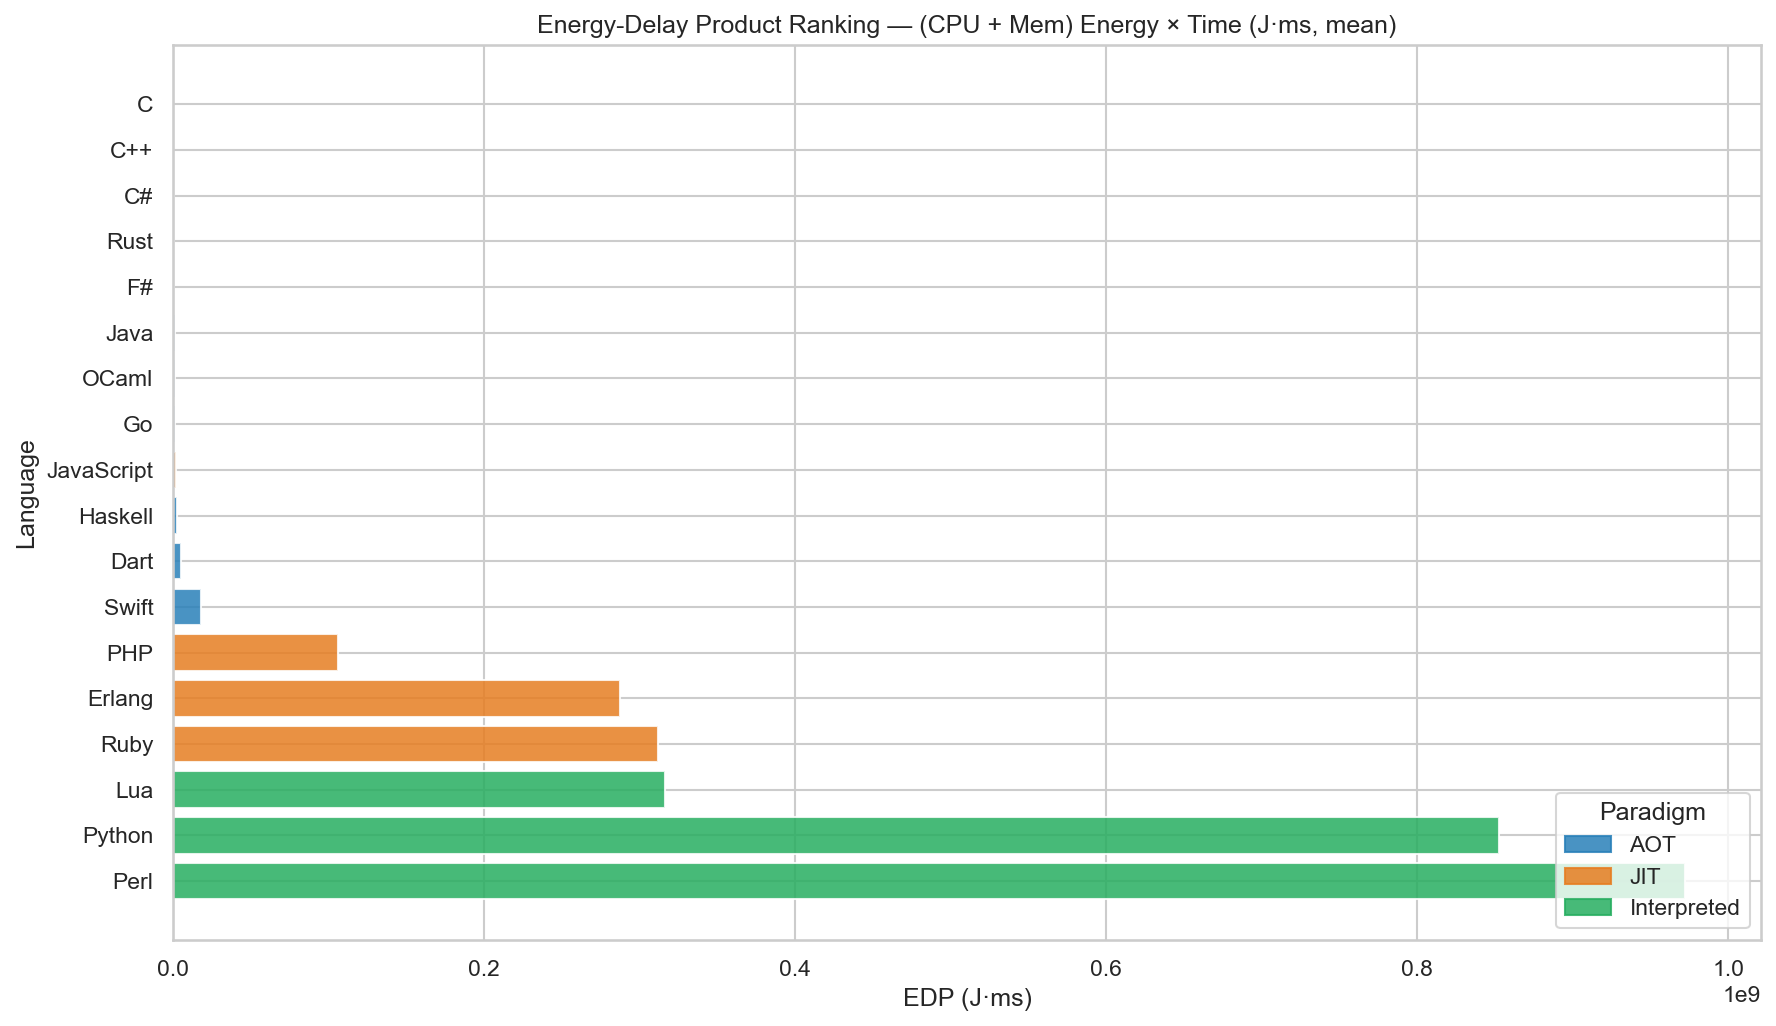

In [8]:
# EDP per cell = (CPU + Mem energy) × time, computed in the load cell on df_mean.
# Two-step mean: average the per-benchmark EDP with equal benchmark weight.
edp_rank = (lang_means('EDP')
              .sort_values()
              .reset_index())
edp_rank.columns = ['language', 'EDP_mean_Jms']
edp_rank['paradigm'] = edp_rank['language'].map(PARADIGM)

print("EDP Ranking — lower is better (unit: J·ms):")
print(edp_rank[['language', 'paradigm', 'EDP_mean_Jms']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))
colors = [PARADIGM_COLORS[p] for p in edp_rank['paradigm']]
ax.barh(edp_rank['language'], edp_rank['EDP_mean_Jms'], color=colors, alpha=0.85, edgecolor='white')
ax.set_title('Energy-Delay Product Ranking — (CPU + Mem) Energy × Time (J·ms, mean)', fontsize=12)
ax.set_xlabel('EDP (J·ms)')
ax.set_ylabel('Language')
ax.invert_yaxis()
legend_handles = [mpatches.Patch(color=PARADIGM_COLORS[p], label=p, alpha=0.85)
                  for p in PARADIGM_ORDER]
ax.legend(handles=legend_handles, title='Paradigm', loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'edp_ranking.png', bbox_inches='tight')
plt.show()

## 6. Benchmark-Level Time Heatmap

Mean execution time (ms) for each language × benchmark cell (the per-cell means stored in
`results_clean.csv`). Reveals which benchmarks are the slowest and which languages suffer
most on specific workloads.

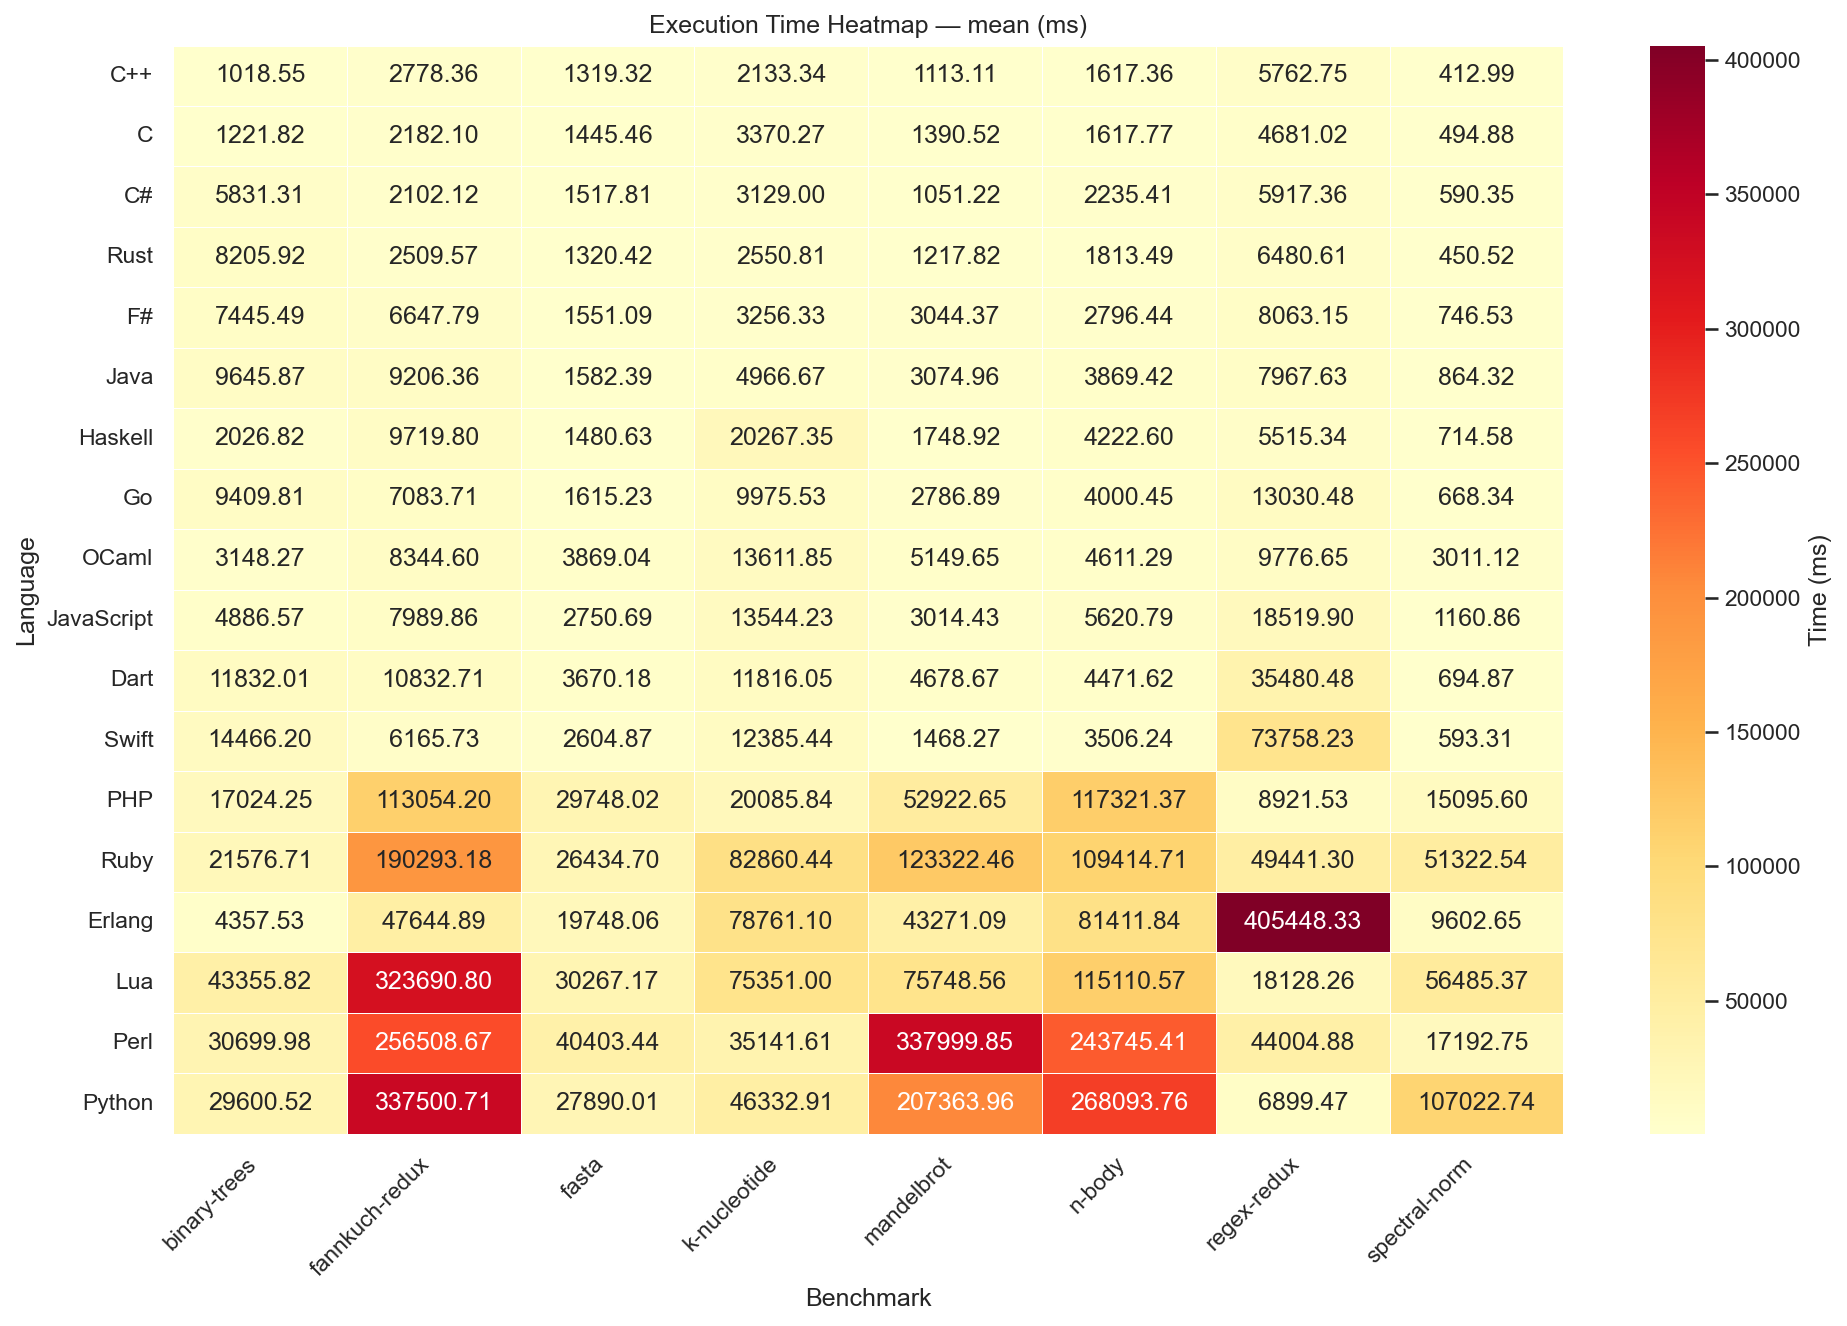

In [9]:
pivot_time = df_mean.pivot(index='language', columns='benchmark', values=COL_TIME)
lang_sort = lang_means(COL_TIME).sort_values().index
pivot_time = pivot_time.loc[lang_sort]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Time (ms)'})
ax.set_title('Execution Time Heatmap — mean (ms)', fontsize=12)
ax.set_xlabel('Benchmark')
ax.set_ylabel('Language')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'time_heatmap_benchmark.png', bbox_inches='tight')
plt.show()